# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [286]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics

In [287]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [288]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [289]:
# put your answer here
df.head(n=5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [290]:
# put your answer here
df.shape

(800, 13)


List all columns available (3 pts)

In [291]:
# put your answer here
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [292]:
# put your answer here
df_selected = df[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]]
df_selected.head(n=5)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


Are there any missing values? (2 pts)

In [293]:
# put your answer here
df_selected.isnull().sum()

,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


If missing values exist, describe how you handled them (3 pts)

In [294]:
# No Missing Values

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [308]:
# put your answer here
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(df_scaled, columns=df_selected.columns)
df_scaled.head(n=5)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,-0.950626,-0.924906,-0.797154,-0.239130,-0.248189,-0.801503
1,-0.362822,-0.524130,-0.347917,0.219560,0.291156,-0.285015
2,0.420917,0.092448,0.293849,0.831146,1.010283,0.403635
3,0.420917,0.647369,1.577381,1.503891,1.729409,0.403635
4,-1.185748,-0.832419,-0.989683,-0.392027,-0.787533,-0.112853


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

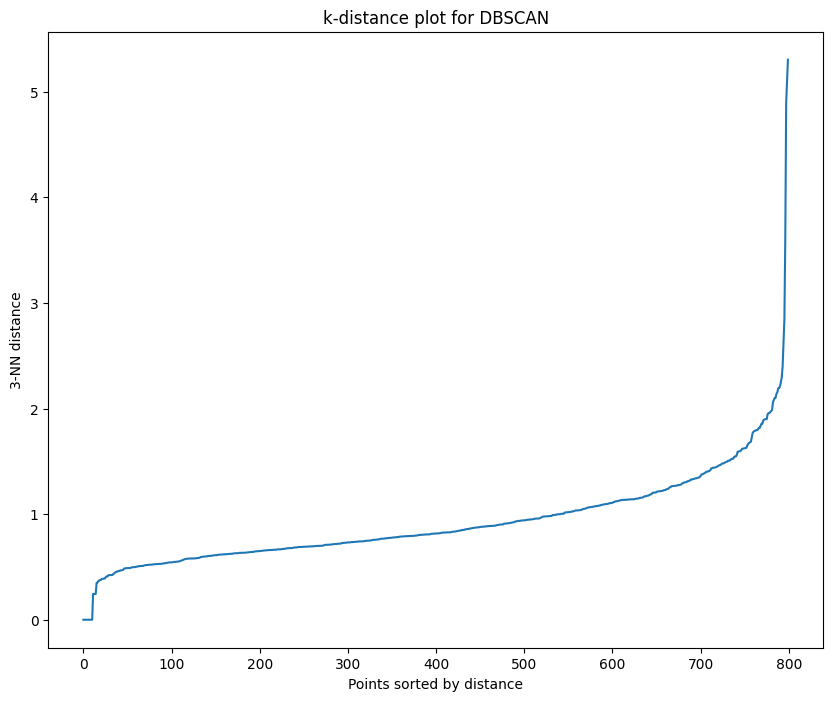

In [344]:
# put your answer here
nn = NearestNeighbors(n_neighbors=4).fit(df_scaled)
distances, indices = nn.kneighbors(df_scaled)

distances = np.sort(distances[:, 3])

plt.figure(figsize=(10, 8))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("3-NN distance")
plt.title("k-distance plot for DBSCAN")
plt.show()

In [298]:
print(distances.min(), distances.max())

0.0 5.302869571790642


What is your chosen eps based on the "elbow"? (2 pts)

In [347]:
# put your answer here
min_samples = range(3,5)
epsilon = np.arange(0.7, 1.3, 0.1)
epsilon

array([0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3])

One-sentence explanation of your reasoning (2 pts)

I chose 1 to 2 because thats where the elbow is, a little above where the line increases significanlty.

In [348]:
output = []

for ms in min_samples:
    for ep in epsilon:
        labels = DBSCAN(min_samples=ms, eps = ep).fit(df_scaled).labels_
        score = metrics.silhouette_score(df_scaled, labels)
        output.append((ms, ep, score))

min_samples, eps, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"min_samples: {min_samples}")
print(f"eps: {eps}")

Best silhouette_score: 0.2761535930776752
min_samples: 3
eps: 1.2999999999999998


## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [349]:
# put your answer here
ep = eps
dbscan = DBSCAN(eps = ep).fit(df_scaled)
labels = dbscan.labels_

# Number of clusters in labels
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise
n_noise_ = list(labels).count(-1)

silhouette_score = metrics.silhouette_score(df_scaled, labels)

In [350]:
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print("Silhouette scrore", silhouette_score)

Estimated number of clusters: 3
Estimated number of noise points: 78
Silhouette scrore 0.1998287582091801


How many Pokémon were labeled as noise? (4 pts)

37 Pokemon are labeled as noise

Show the unique labels output by DBSCAN (2 pts)

In [351]:
unique_labels = set(labels)
unique_labels

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2)}

## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [358]:
# put your answer here
df_selected["cluster"] = labels

/tmp/ipython-input-539452436.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["cluster"] = labels


Show the first 10 rows including the cluster label (4 pts)

In [359]:
# put your answer here
df_selected.head(n=10)

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,cluster
0,45,49,49,65,65,45,0
1,60,62,63,80,80,60,0
2,80,82,83,100,100,80,0
3,80,100,123,122,120,80,0
4,39,52,43,60,50,65,0
5,58,64,58,80,65,80,0
6,78,84,78,109,85,100,0
7,78,130,111,130,85,100,0
8,78,104,78,159,115,100,0
9,44,48,65,50,64,43,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [360]:
# put your answer here
df_selected["cluster"].value_counts()

,count
cluster,
0,709
-1,78
2,8
1,5


What are the average Attack, Defense, and Speed? (4 pts)


In [361]:
# put your answer here
df_selected.groupby("cluster").mean()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster,,,,,,
-1,88.474359,98.794872,94.410256,91.166667,94.089744,73.897436
0,66.521862,76.390691,70.757405,70.234133,68.630465,67.517630
1,62.000000,56.400000,152.600000,59.400000,147.600000,46.000000
2,129.000000,131.500000,97.500000,131.500000,98.250000,94.750000


Compare the clusters: What differences do you notice? (4 pts)

Cluster 0 contains lower to medium stats pokemons

Cluster 1 contains high defense pokemons

Cluster 2 contains high stats pokemons

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [363]:
# put your answer here
df[df_selected["cluster"] == -1]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
19,15,BeedrillMega Beedrill,Bug,Poison,495,65,150,40,15,80,145,1,False,-1
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False,-1
45,40,Wigglytuff,Normal,Fairy,435,140,70,45,85,50,45,1,False,-1
68,63,Abra,Psychic,NaN,310,25,20,15,105,55,90,1,False,-1
69,64,Kadabra,Psychic,NaN,400,40,35,30,120,70,105,1,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,713,Avalugg,Ice,NaN,514,95,117,184,44,46,28,6,False,-1
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,-1
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,-1
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,-1


Are many of them legendary? (3 pts)

In [364]:
# 20 of them are legendary
df[df_selected["cluster"] == -1]["Legendary"].value_counts()

,count
Legendary,
False,58
True,20


Explain why DBSCAN might classify them as outliers (3 pts)

Out of 78 Pokémon, 20 of the noise points (-1) are legendary. DBSCAN identifies them as outliers because legendary Pokémon are rare and have extreme or unusual stats that do not form a dense cluster with other Pokémon.

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

Average Pokémon with balanced stats formed one cluster.
Very defensive Pokémon with extremely high Defense and Special Defense formed another cluster.
Strong Pokémon with consistently high stats, including many legendaries, formed a separate cluster.

Whether the clusters make intuitive sense (10 pts)

Yes, the clusters align with gameplay roles.
Average fighters are grouped together, defensive tanks form their own cluster, and high-power legendary Pokémon are clearly separated.


What the noise points reveal about DBSCAN (5 pts)


Noise points mostly consist of legendary Pokémon.
They are pokemons that have extreme or unusual stat combinations that do not meet DBSCAN’s density requirement.
This shows us that DBSCAN labels rare or isolated points as outliers.

What stat patterns you discovered (5 pts)

Clusters are differentiated by combinations of HP, Attack, Defense, Special Attack, Special Defense, and Speed. Average Pokémon have moderate stats across all features. Defensive Pokémon are extremely high in Defense/Sp. Def but low in Speed and Attack. Lastly, strong or legendary Pokémon are high across most stats, including Speed, Attack, and Special Attack.